# 🔬 v4: NEITHER Mask Guidance NOR SE Block
### HAM10000 · 7-Class · Swin-B + FPN only (both contributions removed)

**Purpose:**
This is the **lower baseline** for the ablation study.
It uses the same sqrt sampler and MixUp as v4, but with no mask guidance
and no SE block. This isolates the contribution of those two additions
by providing a controlled baseline that shares all other improvements.

**What changed vs v3:**
- ❌ Mask guidance REMOVED
- ❌ SE block REMOVED
- ✅ Sqrt WeightedRandomSampler KEPT
- ✅ MixUp alpha=0.4, prob=0.3 KEPT
- ✅ Same dataset, same split (random_state=42), same training config

**Why this is not v2:**
v2 used the WRONG sampler (1/count instead of 1/sqrt(count)).
Ablation-C uses the CORRECT sqrt sampler — so any difference
between Ablation-C and v4 is purely due to mask + SE, not the sampler.

## STEP 1 — Check GPU

In [1]:
import torch
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device    : {DEVICE}')

PyTorch version : 2.5.1+cu121
CUDA available  : True
GPU             : NVIDIA GeForce RTX 3060
Using device    : cuda


## STEP 2 — Install Dependencies

In [2]:
!pip install -q timm albumentations scikit-learn grad-cam lime
print('Done.')

Done.


## STEP 3 — Imports

In [3]:
import os, random, warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

try:
    from torch.amp import GradScaler, autocast
except ImportError:
    from torch.cuda.amp import GradScaler, autocast

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
from PIL import Image
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print(f'albumentations : {A.__version__}')
print(f'timm           : {timm.__version__}')

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\albumentations\check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno 11001] getaddrinfo failed>
  data = fetch_version_info()


albumentations : 2.0.8
timm           : 1.0.22


## STEP 4 — Configuration

In [4]:
# ── Edit only these paths ─────────────────────────────────────────────────────
IMAGE_DIR       = r'D:\SkinLesionClassifier_v4_(C)\data\classification\images'
METADATA_CSV    = r'D:\SkinLesionClassifier_v4_(C)\metadata\HAM10000_metadata.csv'
ENCODER_WEIGHTS = r'D:\SkinLesionClassifier_v4_(C)\models\swinunet_v4_encoder.pth'
SAVE_DIR        = r'D:\SkinLesionClassifier_v4_(C)\outputs\ablation_c_neither'
# ──────────────────────────────────────────────────────────────────────────────

USE_MASK_GUIDANCE = False   # ← REMOVED
USE_SE_BLOCK      = False   # ← REMOVED

IMG_SIZE        = 224
BATCH_SIZE      = 32
NUM_WORKERS     = 0
PIN_MEMORY      = (DEVICE == 'cuda')

PHASE1_EPOCHS   = 10
PHASE1_LR       = 1e-3
PHASE2_EPOCHS   = 50
PHASE2_LR       = 1e-5
WEIGHT_DECAY    = 1e-4
PATIENCE        = 10
LABEL_SMOOTHING = 0.1
MIXUP_ALPHA     = 0.4
MIXUP_PROB      = 0.3

TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15

CLASS_NAMES  = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
CLASS_LABELS = {name: idx for idx, name in enumerate(CLASS_NAMES)}
NUM_CLASSES  = len(CLASS_NAMES)

os.makedirs(SAVE_DIR, exist_ok=True)
MODEL_SAVE_PATH = os.path.join(SAVE_DIR, 'ablation_c_best.pth')
REPORT_PATH     = os.path.join(SAVE_DIR, 'classification_report.txt')
CONF_MAT_PATH   = os.path.join(SAVE_DIR, 'confusion_matrix.png')
CURVE_PATH      = os.path.join(SAVE_DIR, 'training_curves.png')
XAI_DIR         = os.path.join(SAVE_DIR, 'xai_outputs')
os.makedirs(XAI_DIR, exist_ok=True)

print(f'Device           : {DEVICE}')
print(f'USE_MASK_GUIDANCE : {USE_MASK_GUIDANCE}  ← removed')
print(f'USE_SE_BLOCK      : {USE_SE_BLOCK}  ← removed  (Ablation-C)')
print(f'Phase 1           : {PHASE1_EPOCHS} epochs, LR={PHASE1_LR}')
print(f'Phase 2           : {PHASE2_EPOCHS} epochs, LR={PHASE2_LR}')
print(f'MixUp             : alpha={MIXUP_ALPHA}, prob={MIXUP_PROB}')
print(f'Save dir          : {SAVE_DIR}')

Device           : cuda
USE_MASK_GUIDANCE : False  ← removed
USE_SE_BLOCK      : False  ← removed  (Ablation-C)
Phase 1           : 10 epochs, LR=0.001
Phase 2           : 50 epochs, LR=1e-05
MixUp             : alpha=0.4, prob=0.3
Save dir          : D:\SkinLesionClassifier_v4_(C)\outputs\ablation_c_neither


## STEP 5 — Load Metadata & Compute Class Weights

In [5]:
df = pd.read_csv(METADATA_CSV)

def image_exists(image_id):
    for ext in ['.jpg', '.jpeg', '.png']:
        if os.path.exists(os.path.join(IMAGE_DIR, image_id + ext)):
            return True
    return False

df = df[df['image_id'].apply(image_exists)].reset_index(drop=True)
df['label'] = df['dx'].map(CLASS_LABELS)
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

print(f'Total valid samples: {len(df)}')
print('\nClass distribution:')
for cls in CLASS_NAMES:
    count = (df['dx'] == cls).sum()
    pct   = 100 * count / len(df)
    bar   = '█' * int(pct / 2)
    print(f'  {cls:6s}: {count:5d}  ({pct:5.1f}%)  {bar}')

class_counts         = np.array([(df['label'] == i).sum() for i in range(NUM_CLASSES)], dtype=np.float32)
class_weights        = 1.0 / (class_counts + 1e-6)
class_weights        = class_weights / class_weights.sum() * NUM_CLASSES
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print('\nClass weights (for loss):')
for cls, w in zip(CLASS_NAMES, class_weights):
    print(f'  {cls:6s}: {w:.4f}')

Total valid samples: 10015

Class distribution:
  akiec :   327  (  3.3%)  █
  bcc   :   514  (  5.1%)  ██
  bkl   :  1099  ( 11.0%)  █████
  df    :   115  (  1.1%)  
  mel   :  1113  ( 11.1%)  █████
  nv    :  6705  ( 66.9%)  █████████████████████████████████
  vasc  :   142  (  1.4%)  

Class weights (for loss):
  akiec : 0.9431
  bcc   : 0.6000
  bkl   : 0.2806
  df    : 2.6816
  mel   : 0.2771
  nv    : 0.0460
  vasc  : 2.1717


## STEP 6 — Train / Val / Test Split

In [6]:
# CRITICAL: random_state=42 — identical to v4 and Ablation-A for valid comparison
train_df, tmp_df = train_test_split(
    df, test_size=(VAL_RATIO + TEST_RATIO),
    stratify=df['label'], random_state=42
)
val_df, test_df = train_test_split(
    tmp_df, test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    stratify=tmp_df['label'], random_state=42
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print('Split identical to v4 and Ablation-A (random_state=42) ✅')

Train: 7010 | Val: 1502 | Test: 1503
Split identical to v4 and Ablation-A (random_state=42) ✅


## STEP 7 — Dataset & DataLoader (images only — no mask)

In [7]:
class HAMDataset(Dataset):
    """Ablation-C: image-only dataset. No mask loading needed."""
    def __init__(self, dataframe, image_dir, transform=None):
        self.df        = dataframe
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _find_image(self, image_id):
        for ext in ['.jpg', '.jpeg', '.png']:
            p = os.path.join(self.image_dir, image_id + ext)
            if os.path.exists(p):
                return p
        raise FileNotFoundError(f'Image not found: {image_id}')

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        path  = self._find_image(row['image_id'])
        image = np.array(Image.open(path).convert('RGB'))
        label = int(row['label'])
        if self.transform:
            image = self.transform(image=image)['image']
        return image, label


_albu_ver = tuple(int(x) for x in A.__version__.split('.')[:2])
if _albu_ver >= (1, 4):
    _coarse  = A.CoarseDropout(num_holes_range=(1, 4), hole_height_range=(16, 32),
                                hole_width_range=(16, 32), p=0.2)
    _elastic = A.ElasticTransform(p=0.2)
else:
    _coarse  = A.CoarseDropout(max_holes=4, max_height=32, max_width=32, p=0.2)
    _elastic = A.ElasticTransform(alpha=120, sigma=120 * 0.05, p=0.2)

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5), A.Rotate(limit=30, p=0.4),
    _elastic,
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.4),
    A.CLAHE(clip_limit=2.0, p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    _coarse,
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

train_dataset = HAMDataset(train_df, IMAGE_DIR, train_transform)
val_dataset   = HAMDataset(val_df,   IMAGE_DIR, eval_transform)
test_dataset  = HAMDataset(test_df,  IMAGE_DIR, eval_transform)

# Sqrt WeightedRandomSampler — identical to v4
train_labels       = train_df['label'].values
train_class_counts = np.bincount(train_labels, minlength=NUM_CLASSES).astype(np.float32)
sample_weights     = 1.0 / np.sqrt(train_class_counts[train_labels])
sampler            = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).float(),
    num_samples=len(train_dataset), replacement=True
)

sqrt_w = 1.0 / np.sqrt(train_class_counts)
max_w  = sqrt_w.max()
print('Sqrt sample weights (identical to v4):')
for cls, cnt, w in zip(CLASS_NAMES, train_class_counts, sqrt_w):
    bar = '█' * int(w / max_w * 20)
    print(f'  {cls:6s}: {int(cnt):4d} → weight {w:.5f}  {bar}')
print(f'  DF:NV ratio: {sqrt_w[3]/sqrt_w[5]:.1f}x')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f'\nTrain batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Sqrt sample weights (identical to v4):
  akiec :  229 → weight 0.06608  ███████████
  bcc   :  360 → weight 0.05270  █████████
  bkl   :  769 → weight 0.03606  ██████
  df    :   81 → weight 0.11111  ████████████████████
  mel   :  779 → weight 0.03583  ██████
  nv    : 4693 → weight 0.01460  ██
  vasc  :   99 → weight 0.10050  ██████████████████
  DF:NV ratio: 7.6x

Train batches: 220 | Val: 47 | Test: 47


## STEP 8 — Model Architecture

**Ablation-C:** No mask guidance. No SE block.
Identical to v3 in architecture, but uses the CORRECT sqrt sampler.
This is the cleanest baseline to isolate the mask+SE contribution.

In [8]:
# ── FPN — identical to v4 ────────────────────────────────────────────────────
class FPN(nn.Module):
    def __init__(self, in_channels_list, out_channels=256):
        super().__init__()
        self.lateral_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_ch, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)
            ) for in_ch in in_channels_list
        ])
        self.smooth_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)
            ) for _ in in_channels_list
        ])
        self.out_channels = out_channels

    def forward(self, features):
        laterals = [conv(f) for conv, f in zip(self.lateral_convs, features)]
        for i in range(len(laterals) - 1, 0, -1):
            upsampled = F.interpolate(laterals[i], size=laterals[i-1].shape[2:],
                                      mode='bilinear', align_corners=False)
            laterals[i-1] = laterals[i-1] + upsampled
        return [smooth(lat) for smooth, lat in zip(self.smooth_convs, laterals)]


# ── Ablation-C Classifier — no mask, no SE ───────────────────────────────────
class SkinLesionClassifier_AblationC(nn.Module):
    """
    Ablation-C: NO mask guidance, NO SE block.

    Differences from v4:
      - _apply_mask() NOT called in forward()
      - self.se does NOT exist
      - forward() is the simplest possible version: encode → FPN → GAP → MLP
    This is the correct controlled baseline for the ablation study.
    """
    def __init__(self, num_classes=7, fpn_out=256, dropout=0.4,
                 pretrained_encoder=None):
        super().__init__()

        self.encoder = timm.create_model(
            'swin_base_patch4_window7_224',
            pretrained=False, features_only=True, out_indices=(0, 1, 2, 3)
        )

        if pretrained_encoder is not None:
            ckpt      = torch.load(pretrained_encoder, map_location='cpu', weights_only=False)
            enc_state = ckpt.get('encoder_state_dict', ckpt)
            missing, unexpected = self.encoder.load_state_dict(enc_state, strict=False)
            print(f'  Encoder loaded. Missing: {len(missing)} | Unexpected: {len(unexpected)}')

        with torch.no_grad():
            _d = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
            _f = self.encoder(_d)
            enc_channels = [self._to_spatial(f).shape[1] for f in _f]
        print(f'  Encoder channels: {enc_channels}')
        self.enc_channels = enc_channels

        self.fpn = FPN(enc_channels, out_channels=fpn_out)
        # ← NO self.se

        concat_dim = 4 * fpn_out
        self.classifier = nn.Sequential(
            nn.Linear(concat_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.75),
            nn.Linear(256, num_classes)
        )
        self._init_head()

    def _init_head(self):
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    @staticmethod
    def _to_spatial(x):
        if x.dim() == 4 and x.shape[-1] > x.shape[1]:
            return x.permute(0, 3, 1, 2).contiguous()
        if x.dim() == 3:
            B, L, C = x.shape
            H = W = int(L ** 0.5)
            return x.reshape(B, H, W, C).permute(0, 3, 1, 2).contiguous()
        return x

    def freeze_encoder(self):
        for p in self.encoder.parameters():
            p.requires_grad = False
        print('  ✅ Encoder FROZEN')

    def unfreeze_encoder(self):
        for p in self.encoder.parameters():
            p.requires_grad = True
        print('  ✅ Encoder UNFROZEN (fine-tuning)')

    def trainable_params(self):
        n     = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        print(f'  Trainable: {n/1e6:.1f}M / {total/1e6:.1f}M')

    def forward(self, x, mask=None):
        """mask argument ignored — neither mask nor SE used."""
        enc_feats = [self._to_spatial(f) for f in self.encoder(x)]
        # ← NO _apply_mask()
        pyramid   = self.fpn(enc_feats)
        pooled    = [F.adaptive_avg_pool2d(p, 1).flatten(1) for p in pyramid]
        feat      = torch.cat(pooled, dim=1)
        # ← NO self.se(feat)
        return self.classifier(feat)


print('Building Ablation-C model (no mask, no SE — controlled baseline)...')
model = SkinLesionClassifier_AblationC(
    num_classes=NUM_CLASSES, fpn_out=256, dropout=0.4,
    pretrained_encoder=ENCODER_WEIGHTS
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'\nModel ready | {total_params/1e6:.1f}M total parameters')

with torch.no_grad():
    _img = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    _out = model(_img, mask=None)
    print(f'Output shape: {_out.shape}  ✅')
    print(f'Mask guidance: DISABLED  ✅')
    print(f'SE block     : DISABLED  ✅  (Ablation-C)')

Building Ablation-C model (no mask, no SE — controlled baseline)...
  Encoder loaded. Missing: 0 | Unexpected: 0
  Encoder channels: [128, 256, 512, 1024]

Model ready | 90.3M total parameters
Output shape: torch.Size([2, 7])  ✅
Mask guidance: DISABLED  ✅
SE block     : DISABLED  ✅  (Ablation-C)


## STEP 9 — Loss Function

In [9]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=LABEL_SMOOTHING
)
print(f'Loss : WeightedCrossEntropyLoss (label_smoothing={LABEL_SMOOTHING})')
print(f'Class weights: {[f"{w:.3f}" for w in class_weights]}')

Loss : WeightedCrossEntropyLoss (label_smoothing=0.1)
Class weights: ['0.943', '0.600', '0.281', '2.682', '0.277', '0.046', '2.172']


## STEP 10 — Training & Evaluation Utilities

In [10]:
def mixup_data(images, labels, alpha=MIXUP_ALPHA, device=DEVICE):
    lam          = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index        = torch.randperm(images.size(0), device=device)
    mixed_images = lam * images + (1 - lam) * images[index]
    return mixed_images, labels, labels[index], lam

def mixup_criterion(criterion, logits, label_a, label_b, lam):
    return lam * criterion(logits, label_a) + (1 - lam) * criterion(logits, label_b)

def train_one_epoch(model, loader, optimizer, criterion, scaler, device, use_mixup=True):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc='  Train', leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        apply_mixup = use_mixup and (random.random() < MIXUP_PROB)
        with autocast(device_type=device):
            if apply_mixup:
                mixed_imgs, label_a, label_b, lam = mixup_data(imgs, labels, device=device)
                logits = model(mixed_imgs, mask=None)
                loss   = mixup_criterion(criterion, logits, label_a, label_b, lam)
            else:
                logits = model(imgs, mask=None)
                loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer); scaler.update()
        total_loss += loss.item() * imgs.size(0)
        preds       = logits.argmax(dim=1)
        ref_labels  = labels if not apply_mixup else (label_a if lam >= 0.5 else label_b)
        correct    += (preds == ref_labels).sum().item()
        total      += imgs.size(0)
        pbar.set_postfix(loss=f'{loss.item():.4f}', acc=f'{correct/total:.4f}')
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in tqdm(loader, desc='  Eval ', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        with autocast(device_type=device):
            logits = model(imgs, mask=None)
            loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return (total_loss / total, correct / total,
            f1_score(all_labels, all_preds, average='macro', zero_division=0),
            all_preds, all_labels)

def save_curves(history, path):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, key, title in zip(axes, ['loss','acc','macro_f1'],
                               ['Loss','Accuracy','Macro F1']):
        ax.plot(history['train_'+key], label='Train')
        ax.plot(history['val_'+key],   label='Val')
        ax.set_title(title); ax.set_xlabel('Epoch')
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  Curves saved → {path}')

def save_confusion_matrix(y_true, y_pred, class_names, path, title=''):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'Confusion Matrix — {title}')
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  Confusion matrix saved → {path}')

print(f'Utilities ready. MixUp: alpha={MIXUP_ALPHA}, prob={MIXUP_PROB}')
print('NOTE: All model calls use mask=None — both mask and SE disabled ✅')

Utilities ready. MixUp: alpha=0.4, prob=0.3
NOTE: All model calls use mask=None — both mask and SE disabled ✅


## STEP 11 — Phase 1 Training: Frozen Encoder

In [11]:
print('=' * 65)
print('  ABLATION-C PHASE 1 — Frozen encoder')
print('=' * 65)

model.freeze_encoder()
model.trainable_params()

optimizer_p1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=PHASE1_LR, weight_decay=WEIGHT_DECAY
)
scheduler_p1 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p1, T_max=PHASE1_EPOCHS, eta_min=PHASE1_LR * 0.1
)
scaler = GradScaler()

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'train_macro_f1': [], 'val_macro_f1': []
}
best_val_f1  = 0.0
patience_ctr = 0

for epoch in range(1, PHASE1_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, optimizer_p1, criterion, scaler, DEVICE, use_mixup=True
    )
    vl_loss, vl_acc, vl_f1, _, _ = evaluate(model, val_loader,   criterion, DEVICE)
    _,       tr_acc, tr_f1, _, _ = evaluate(model, train_loader, criterion, DEVICE)

    history['train_loss'].append(tr_loss);    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc);      history['val_acc'].append(vl_acc)
    history['train_macro_f1'].append(tr_f1);  history['val_macro_f1'].append(vl_f1)
    scheduler_p1.step()

    improved = vl_f1 > best_val_f1
    if improved:
        best_val_f1  = vl_f1
        patience_ctr = 0
        torch.save({'model_state_dict': model.state_dict(),
                    'epoch': epoch, 'phase': 1,
                    'best_val_f1': best_val_f1,
                    'ablation': 'C — neither mask nor SE'}, MODEL_SAVE_PATH)
    else:
        patience_ctr += 1

    flag = '✅' if improved else '  '
    print(f'  {flag} Ep {epoch:02d}/{PHASE1_EPOCHS} '
          f'| TrLoss {tr_loss:.4f} TrAcc {tr_acc:.4f} TrF1 {tr_f1:.4f} '
          f'| VlLoss {vl_loss:.4f} VlAcc {vl_acc:.4f} VlF1 {vl_f1:.4f}')

    if patience_ctr >= PATIENCE:
        print(f'  Early stopping at epoch {epoch}')
        break

print(f'\nPhase 1 complete. Best Val Macro-F1: {best_val_f1:.4f}')
save_curves(history, CURVE_PATH.replace('.png', '_phase1.png'))

  ABLATION-C PHASE 1 — Frozen encoder
  ✅ Encoder FROZEN
  Trainable: 3.5M / 90.3M


  ✅ Ep 01/10 | TrLoss 1.4420 TrAcc 0.5083 TrF1 0.5451 | VlLoss 2.0073 VlAcc 0.4194 VlF1 0.4058


  ✅ Ep 02/10 | TrLoss 1.2253 TrAcc 0.4926 TrF1 0.5527 | VlLoss 1.9244 VlAcc 0.2530 VlF1 0.4234


  ✅ Ep 03/10 | TrLoss 1.1101 TrAcc 0.6384 TrF1 0.6726 | VlLoss 1.8894 VlAcc 0.5280 VlF1 0.5207


     Ep 04/10 | TrLoss 1.0431 TrAcc 0.5359 TrF1 0.5737 | VlLoss 1.8756 VlAcc 0.2617 VlF1 0.3715


...

     Ep 06/10 | TrLoss 1.0065 TrAcc 0.5887 TrF1 0.6507 | VlLoss 1.8123 VlAcc 0.3808 VlF1 0.4817


     Ep 07/10 | TrLoss 0.9722 TrAcc 0.5569 TrF1 0.6193 | VlLoss 1.8163 VlAcc 0.2776 VlF1 0.4265


  ✅ Ep 08/10 | TrLoss 0.9070 TrAcc 0.7435 TrF1 0.7754 | VlLoss 1.7852 VlAcc 0.6192 VlF1 0.5669


     Ep 09/10 | TrLoss 0.9557 TrAcc 0.5777 TrF1 0.6454 | VlLoss 1.7773 VlAcc 0.2803 VlF1 0.4546


     Ep 10/10 | TrLoss 0.9016 TrAcc 0.5786 TrF1 0.6459 | VlLoss 1.7792 VlAcc 0.2856 VlF1 0.4567

Phase 1 complete. Best Val Macro-F1: 0.5669
  Curves saved → D:\SkinLesionClassifier_v4_(C)\outputs\ablation_c_neither\training_curves_phase1.png


## STEP 12 — Phase 2 Training: Full Fine-Tune

In [12]:
print('=' * 65)
print('  ABLATION-C PHASE 2 — Full fine-tune | 50 epochs')
print('=' * 65)

ckpt = torch.load(MODEL_SAVE_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f'  Loaded Phase 1 best (epoch {ckpt["epoch"]}, Val F1={ckpt["best_val_f1"]:.4f})')

model.unfreeze_encoder()
model.trainable_params()

encoder_params     = list(model.encoder.parameters())
non_encoder_params = [p for p in model.parameters()
                      if not any(p is ep for ep in encoder_params)]

optimizer_p2 = torch.optim.AdamW([
    {'params': encoder_params,     'lr': PHASE2_LR},
    {'params': non_encoder_params, 'lr': PHASE2_LR * 5}
], weight_decay=WEIGHT_DECAY)

scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p2, T_max=PHASE2_EPOCHS, eta_min=PHASE2_LR * 0.1
)

history2 = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'train_macro_f1': [], 'val_macro_f1': []
}
best_val_f1_p2 = ckpt['best_val_f1']
patience_ctr   = 0

for epoch in range(1, PHASE2_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, optimizer_p2, criterion, scaler, DEVICE, use_mixup=True
    )
    vl_loss, vl_acc, vl_f1, _, _ = evaluate(model, val_loader,   criterion, DEVICE)
    _,       tr_acc, tr_f1, _, _ = evaluate(model, train_loader, criterion, DEVICE)

    history2['train_loss'].append(tr_loss);    history2['val_loss'].append(vl_loss)
    history2['train_acc'].append(tr_acc);      history2['val_acc'].append(vl_acc)
    history2['train_macro_f1'].append(tr_f1);  history2['val_macro_f1'].append(vl_f1)
    scheduler_p2.step()

    improved = vl_f1 > best_val_f1_p2
    if improved:
        best_val_f1_p2 = vl_f1
        patience_ctr   = 0
        torch.save({'model_state_dict': model.state_dict(),
                    'epoch': epoch, 'phase': 2,
                    'best_val_f1': best_val_f1_p2,
                    'ablation': 'C — neither mask nor SE'}, MODEL_SAVE_PATH)
    else:
        patience_ctr += 1

    flag = '✅' if improved else '  '
    print(f'  {flag} Ep {epoch:02d}/{PHASE2_EPOCHS} '
          f'| TrLoss {tr_loss:.4f} TrAcc {tr_acc:.4f} TrF1 {tr_f1:.4f} '
          f'| VlLoss {vl_loss:.4f} VlAcc {vl_acc:.4f} VlF1 {vl_f1:.4f}')

    if patience_ctr >= PATIENCE:
        print(f'  Early stopping triggered at epoch {epoch}.')
        break

print(f'\nPhase 2 complete. Best Val Macro-F1: {best_val_f1_p2:.4f}')
save_curves(history2, CURVE_PATH.replace('.png', '_phase2.png'))

  ABLATION-C PHASE 2 — Full fine-tune | 50 epochs
  Loaded Phase 1 best (epoch 8, Val F1=0.5669)
  ✅ Encoder UNFROZEN (fine-tuning)
  Trainable: 90.3M / 90.3M


     Ep 01/50 | TrLoss 0.9315 TrAcc 0.7104 TrF1 0.7548 | VlLoss 1.7926 VlAcc 0.5246 VlF1 0.5566


     Ep 02/50 | TrLoss 0.9043 TrAcc 0.6223 TrF1 0.6897 | VlLoss 1.7581 VlAcc 0.3502 VlF1 0.5048


     Ep 03/50 | TrLoss 0.9056 TrAcc 0.6053 TrF1 0.6837 | VlLoss 1.7571 VlAcc 0.2909 VlF1 0.4944


     Ep 04/50 | TrLoss 0.8645 TrAcc 0.6161 TrF1 0.6933 | VlLoss 1.7657 VlAcc 0.3369 VlF1 0.5091


...

     Ep 28/50 | TrLoss 0.7720 TrAcc 0.9340 TrF1 0.9349 | VlLoss 1.6975 VlAcc 0.8262 VlF1 0.7289


     Ep 29/50 | TrLoss 0.8113 TrAcc 0.9245 TrF1 0.9250 | VlLoss 1.6946 VlAcc 0.8189 VlF1 0.7336


     Ep 30/50 | TrLoss 0.8171 TrAcc 0.9342 TrF1 0.9331 | VlLoss 1.6948 VlAcc 0.8349 VlF1 0.7333


     Ep 31/50 | TrLoss 0.8060 TrAcc 0.9541 TrF1 0.9463 | VlLoss 1.7252 VlAcc 0.8542 VlF1 0.7336


     Ep 32/50 | TrLoss 0.7918 TrAcc 0.9398 TrF1 0.9409 | VlLoss 1.6904 VlAcc 0.8342 VlF1 0.7303
  Early stopping triggered at epoch 32.

Phase 2 complete. Best Val Macro-F1: 0.7380
  Curves saved → D:\SkinLesionClassifier_v4_(C)\outputs\ablation_c_neither\training_curves_phase2.png


## STEP 13 — Test Set Evaluation

In [13]:
ckpt = torch.load(MODEL_SAVE_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded best: phase {ckpt["phase"]}, epoch {ckpt["epoch"]}, Val F1={ckpt["best_val_f1"]:.4f}')

test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(
    model, test_loader, criterion, DEVICE
)

print('\n' + '=' * 60)
print('  TEST RESULTS — Ablation-C: NO Mask Guidance, NO SE Block')
print('=' * 60)
print(f'  Loss      : {test_loss:.4f}')
print(f'  Accuracy  : {test_acc:.4f}  ({test_acc*100:.1f}%)')
print(f'  Macro F1  : {test_f1:.4f}')
print('=' * 60)

report = classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=4)
print('\nPer-class report:')
print(report)

with open(REPORT_PATH, 'w') as f:
    f.write('Ablation-C: NO Mask Guidance, NO SE Block\n')
    f.write(f'Test Loss     : {test_loss:.4f}\n')
    f.write(f'Test Accuracy : {test_acc:.4f}\n')
    f.write(f'Test Macro F1 : {test_f1:.4f}\n\n')
    f.write(report)
print(f'Report saved → {REPORT_PATH}')

Loaded best: phase 2, epoch 22, Val F1=0.7380



  TEST RESULTS — Ablation-C: NO Mask Guidance, NO SE Block
  Loss      : 1.7006
  Accuracy  : 0.8350  (83.5%)
  Macro F1  : 0.7331

Per-class report:
              precision    recall  f1-score   support

       akiec     0.8222    0.7551    0.7872        49
         bcc     0.8452    0.9221    0.8820        77
         bkl     0.8323    0.7818    0.8063       165
          df     0.1429    0.8824    0.2459        17
         mel     0.6245    0.8563    0.7222       167
          nv     0.9847    0.8330    0.9025      1006
        vasc     0.6471    1.0000    0.7857        22

    accuracy                         0.8350      1503
   macro avg     0.6998    0.8615    0.7331      1503
weighted avg     0.9010    0.8350    0.8580      1503

Report saved → D:\SkinLesionClassifier_v4_(C)\outputs\ablation_c_neither\classification_report.txt


## STEP 14 — Confusion Matrix & Per-Class Accuracy

  Confusion matrix saved → D:\SkinLesionClassifier_v4_(C)\outputs\ablation_c_neither\confusion_matrix.png


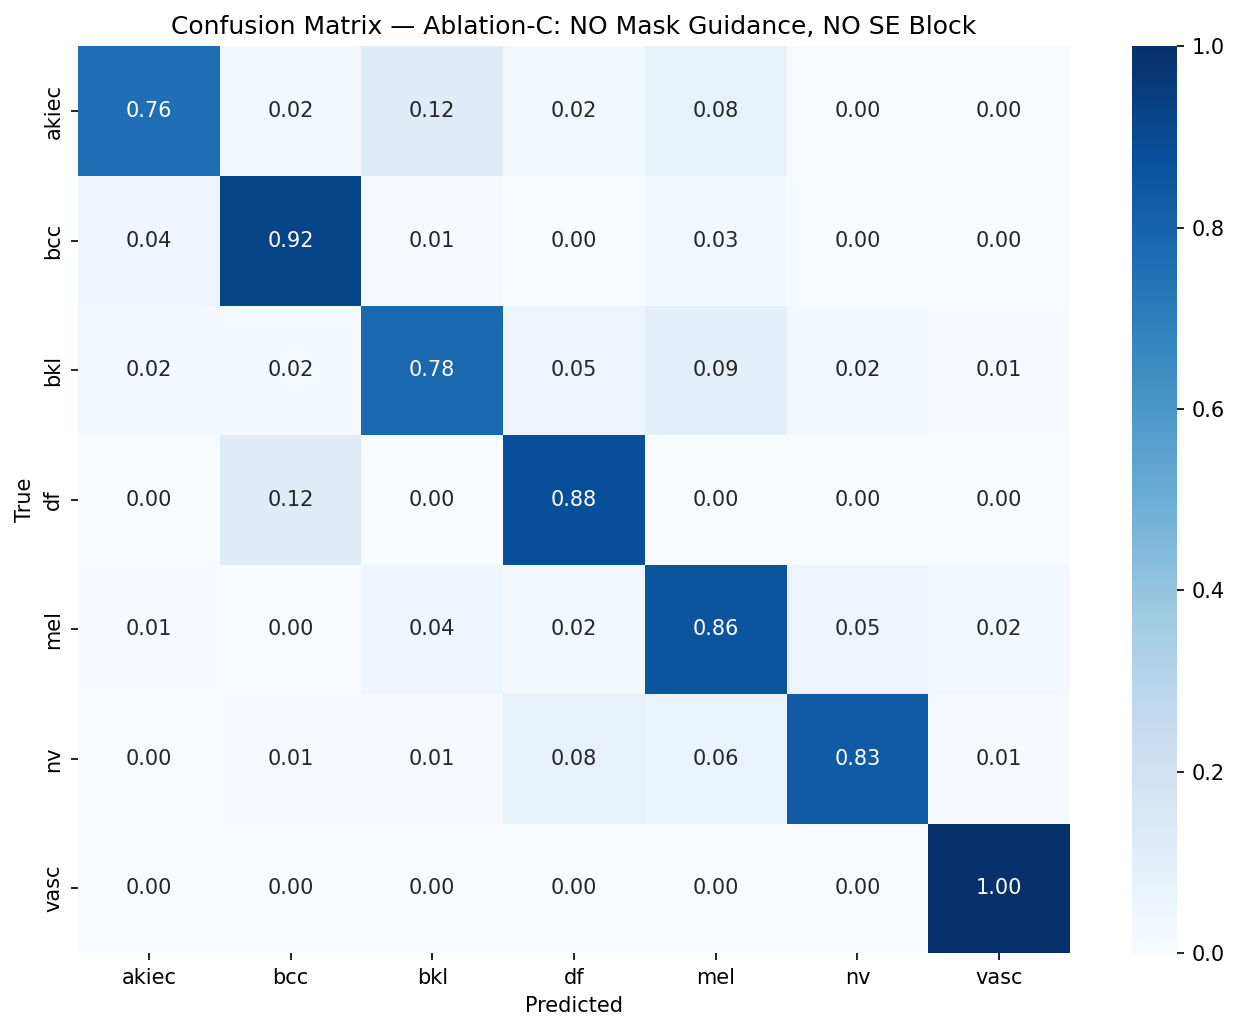

In [14]:
save_confusion_matrix(test_labels, test_preds, CLASS_NAMES,
                       CONF_MAT_PATH, title='Ablation-C: NO Mask Guidance, NO SE Block')
try:
    from IPython.display import Image as IPImage, display
    display(IPImage(CONF_MAT_PATH))
except Exception:
    print(f'Open manually: {CONF_MAT_PATH}')

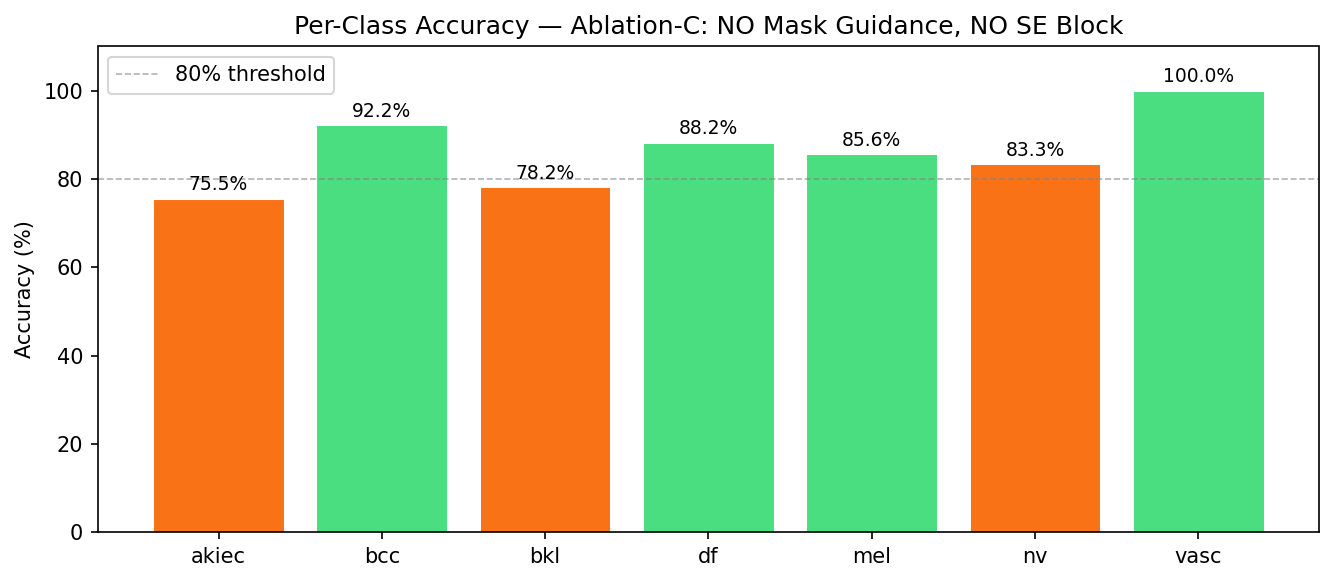


Per-class accuracy:
  akiec :  75.5%  ██████████████████████████████
  bcc   :  92.2%  ████████████████████████████████████
  bkl   :  78.2%  ███████████████████████████████
  df    :  88.2%  ███████████████████████████████████
  mel   :  85.6%  ██████████████████████████████████
  nv    :  83.3%  █████████████████████████████████
  vasc  : 100.0%  ████████████████████████████████████████


In [15]:
cm = confusion_matrix(test_labels, test_preds)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#ef4444' if a < 0.7 else '#f97316' if a < 0.85 else '#4ade80'
          for a in per_class_acc]
bars = ax.bar(CLASS_NAMES, per_class_acc * 100, color=colors,
              edgecolor='white', linewidth=0.5)
ax.set_ylim(0, 110)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Accuracy — Ablation-C: NO Mask Guidance, NO SE Block')
ax.axhline(80, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='80% threshold')
ax.legend()
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
bar_path = CONF_MAT_PATH.replace('confusion_matrix', 'per_class_acc')
plt.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.close()

try:
    from IPython.display import Image as IPImage, display
    display(IPImage(bar_path))
except Exception:
    pass

print('\nPer-class accuracy:')
for cls, acc in zip(CLASS_NAMES, per_class_acc):
    print(f'  {cls:6s}: {acc*100:5.1f}%  ' + '█' * int(acc * 40))

## STEP 15 — Summary & Ablation Table

In [16]:
print('╔══════════════════════════════════════════════════════════════════╗')
print('║  Ablation-C: NO Mask Guidance, NO SE Block                       ║')
print('╠══════════════════════════════════════════════════════════════════╣')
print(f'║  Test Loss     : {test_loss:.4f}                                       ║')
print(f'║  Test Accuracy : {test_acc:.4f}  ({test_acc*100:.1f}%)                          ║')
print(f'║  Test Macro F1 : {test_f1:.4f}                                       ║')
print('╠══════════════════════════════════════════════════════════════════╣')
print('║  ABLATION TABLE (fill in after all runs complete)                ║')
print('║  Model                          | Macro F1 | Key difference       ║')
print('║  v1 (no sampler, no SE, no mask)| 0.7886   | original baseline    ║')
print('║  Ablation-A (SE only)           | TBD      | proves SE alone      ║')
print('║  Ablation-B (mask only)         | TBD      | proves mask alone    ║')
print('║  Ablation-C (neither)           | TBD      | sqrt+mixup baseline  ║')
print('║  v4 FULL (mask + SE)            | TBD      | full method          ║')
print('╚══════════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════════╗
║  Ablation-C: NO Mask Guidance, NO SE Block                       ║
╠══════════════════════════════════════════════════════════════════╣
║  Test Loss     : 1.7006                                       ║
║  Test Accuracy : 0.8350  (83.5%)                          ║
║  Test Macro F1 : 0.7331                                       ║
╠══════════════════════════════════════════════════════════════════╣
║  ABLATION TABLE (fill in after all runs complete)                ║
║  Model                          | Macro F1 | Key difference       ║
║  v1 (no sampler, no SE, no mask)| 0.7886   | original baseline    ║
║  Ablation-A (SE only)           | TBD      | proves SE alone      ║
║  Ablation-B (mask only)         | TBD      | proves mask alone    ║
║  Ablation-C (neither)           | TBD      | sqrt+mixup baseline  ║
║  v4 FULL (mask + SE)            | TBD      | full method          ║
╚════════════════════════════════════════